In [1]:
from qnca import qnca
from qnca import ca_patterns
from qnca.optimizers import base, cobyla, cma, ga, grid
from qnca.ca_patterns import  rules
from qnca.operators import get_id

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch

dispositivo = 'GPU' if torch.cuda.is_available() else 'CPU'

In [2]:
#DIRETORIO_PADRAO = 'D:\\Dropbox\\Projetos\\pessoal\\QNCA\\results\\'
DIRETORIO_PADRAO = 'C:\\Users\\petro\\Dropbox\\Projetos\\pessoal\\QNCA\\tests\\'

In [3]:
pattern = np.array(rules[28])

n,T = pattern.shape

vqca = qnca.QNCA(n = n, initial = pattern[0,:], operator = get_id(n, 23), T = T, iqp = True)

vqca.qc.draw()

┌───┐                                                                    »
q_0: ┤ H ├──────■─────────────────────■──────────────────────■────────────────»
     ├───┤┌───┐ │                     │                      │                »
q_1: ┤ X ├┤ H ├─■──────────────■──────┼──────────────────────■────────────────»
     ├───┤└───┘ │              │      │                      │                »
q_2: ┤ H ├──────┼──────────────■──────┼───────■──────────────┼────────────────»
     ├───┤      │              │      │       │              │                »
q_3: ┤ H ├──────┼──────────────┼──────┼───────■──────────────┼──■─────────────»
     ├───┤      │              │      │       │              │  │             »
q_4: ┤ H ├──────┼──────────────┼──────■───────┼──────────────┼──■─────────────»
     ├───┤      │ ┌──────────┐ │      │       │ ┌──────────┐ │  │    ┌───┐    »
q_5: ┤ H ├──────■─┤ Rz(ϴ[0]) ├─┼──────■───────┼─┤ Rz(ϴ[1]) ├─┼──┼────┤ H ├────»
     ├───┤        └──────────┘ │ ┌──────────┐ │ └──────────┘ │  │ ┌──┴───┴───┐»
q_6: ┤ H ├─────────────────────■─┤ Rz(ϴ[0]) ├─┼──────────────■──┼─┤ Rz(ϴ[1]) ├»
     ├───┤                       └──────────┘ │ ┌──────────┐    │ └──────────┘»
q_7: ┤ H ├────────────────────────────────────■─┤ Rz(ϴ[0]) ├────┼─────────────»
     ├───┤                                      └──────────┘    │ ┌──────────┐»
q_8: ┤ H ├──────────────────────────────────────────────────────■─┤ Rz(ϴ[0]) ├»
     ├───┤                                                        └──────────┘»
q_9: ┤ H ├────────────────────────────────────────────────────────────────────»
     └───┘                                                                    »
c: 5/═════════════════════════════════════════════════════════════════════════»
                                                                              »
«              ┌───┐                                  ┌───┐                »
«q_0: ────■────┤ H ├───────────────────────────X──────┤ H ├────────────────»
«         │    ├───┤                           │      └───┘┌───┐           »
«q_1: ─■──┼────┤ H ├───────────────────────────┼────────X──┤ H ├───────────»
«      │  │    └───┘          ┌───┐            │        │  └───┘   ┌───┐   »
«q_2: ─■──┼──────────────■────┤ H ├────────────┼────────┼────────X─┤ H ├───»
«      │  │              │    └───┘            │        │  ┌───┐ │ └───┘   »
«q_3: ─┼──┼──────────────■──────────────■──────┼────────┼──┤ H ├─┼───────X─»
«      │  │              │              │      │        │  ├───┤ │       │ »
«q_4: ─┼──■──────────────┼──────────────■──────┼────────┼──┤ H ├─┼───────┼─»
«      │  │              │              │      │        │  └───┘ │ ┌───┐ │ »
«q_5: ─┼──┼──────────────┼──────────────┼──────X────────┼───|0>──┼─┤ H ├─┼─»
«      │  │    ┌───┐     │              │               │        │ ├───┤ │ »
«q_6: ─┼──┼────┤ H ├─────┼──────────────┼───────────────X───|0>──┼─┤ H ├─┼─»
«      │  │ ┌──┴───┴───┐ │    ┌───┐     │                        │ └───┘ │ »
«q_7: ─■──┼─┤ Rz(ϴ[1]) ├─┼────┤ H ├─────┼────────────────────────X──|0>──┼─»
«         │ └──────────┘ │ ┌──┴───┴───┐ │    ┌───┐                       │ »
«q_8: ────┼──────────────■─┤ Rz(ϴ[1]) ├─┼────┤ H ├───────────────────────X─»
«         │ ┌──────────┐   └──────────┘ │ ┌──┴───┴───┐┌───┐                »
«q_9: ────■─┤ Rz(ϴ[0]) ├────────────────■─┤ Rz(ϴ[1]) ├┤ H ├────────────────»
«           └──────────┘                  └──────────┘└───┘                »
«c: 5/═════════════════════════════════════════════════════════════════════»
«                                                                          »
«                                                                              »
«q_0: ──────────■──────────────────────■──────────────────────■────────────────»
«               │                      │                      │                »
«q_1: ──────────■───────────────■──────┼──────────────────────■────────────────»
«               │               │      │                      │       

In [5]:
pattern = rules[28]

n = len(pattern[0])

optm = cobyla.QNCAOptimizerCOBYLA(pattern = np.array(rules[1]), hadamard = False, operator = OperatorIQP(n=n),  noise = False)

optm.training_loop()

NEW MIN: 5.465564738292011	[1.3896258892028328, 3.847729959426654, 4.337580533468852, 5.57177974685798, 1.7211674297341386, 3.816656994657446]
NEW MIN: 5.0	[2.389625889202833, 3.847729959426654, 4.337580533468852, 5.57177974685798, 1.7211674297341386, 3.816656994657446]
NEW MIN: 4.960514233241506	[2.389625889202833, 3.847729959426654, 5.337580533468852, 5.57177974685798, 1.7211674297341386, 3.816656994657446]
NEW MIN: 4.957759412304867	[2.389625889202833, 3.847729959426654, 5.337580533468852, 6.57177974685798, 1.7211674297341386, 3.816656994657446]
NEW MIN: 4.880624426078971	[2.389625889202833, 3.847729959426654, 5.337580533468852, 6.57177974685798, 1.7211674297341386, 4.816656994657446]
NEW MIN: 4.791551882460974	[2.368498583495509, 3.847729959426654, 5.5866862077389285, 6.57177974685798, 1.7211674297341386, 4.816656994657446]
NEW MIN: 4.609733700642791	[2.5008111743592023, 3.8603388578692264, 5.656265789493153, 6.216348380026821, 2.038977336993335, 4.82924596214266]
NEW MIN: 4.593204

 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: 4.757575757575757
       x: [ 2.504e+00  3.862e+00  5.657e+00  6.217e+00  2.038e+00
            4.829e+00]
    nfev: 60
   maxcv: 0.0

In [7]:
pattern = rules[28]

n = len(pattern[0])

optm = ga.QNCAOptimizerGA(pattern = np.array(rules[1]), iqp = True, operator = get_id(n, 61),  noise = False)

optm.training_loop()

NEW MIN: 6.743801652892562	[0.32003864480732735, 2.1767320856263854, 0.4022400735306754, 1.8351043063947348, 2.5442642262733477, 4.469358630688098]
NEW MIN: 5.400367309458221	[2.511140232134022, 5.51197696927627, 4.664622513211066, 3.650256360431364, 1.9726313729404619, 0.22641323532649596]
NEW MIN: 4.114784205693296	[1.4228404909030938, 5.826005103831804, 1.1135990620620067, 5.229896810722261, 5.778872341812775, 5.394485629046271]
NEW MIN: 4.086317722681359	[2.7679851127774238, 1.7571115294525579, 2.209398506917837, 2.564386775272956, 5.592609542331038, 5.739772588967606]
NEW MIN: 3.453627180899907	[5.010292038128574, 2.142894911133241, 3.8961852239677297, 3.9022794435476262, 0.21697443140298062, 2.4374996161512144]
NEW MIN: 2.5871893976163562	[5.010292038128574, 2.142894911133241, 3.8961852239677297, 3.9022794435476262, 0.21697443140298062, 2.4374996161512144]
NEW MIN: 2.337681661199736	[5.010292038128574, 2.142894911133241, 3.8961852239677297, 3.9022794435476262, 0.21697443140298062

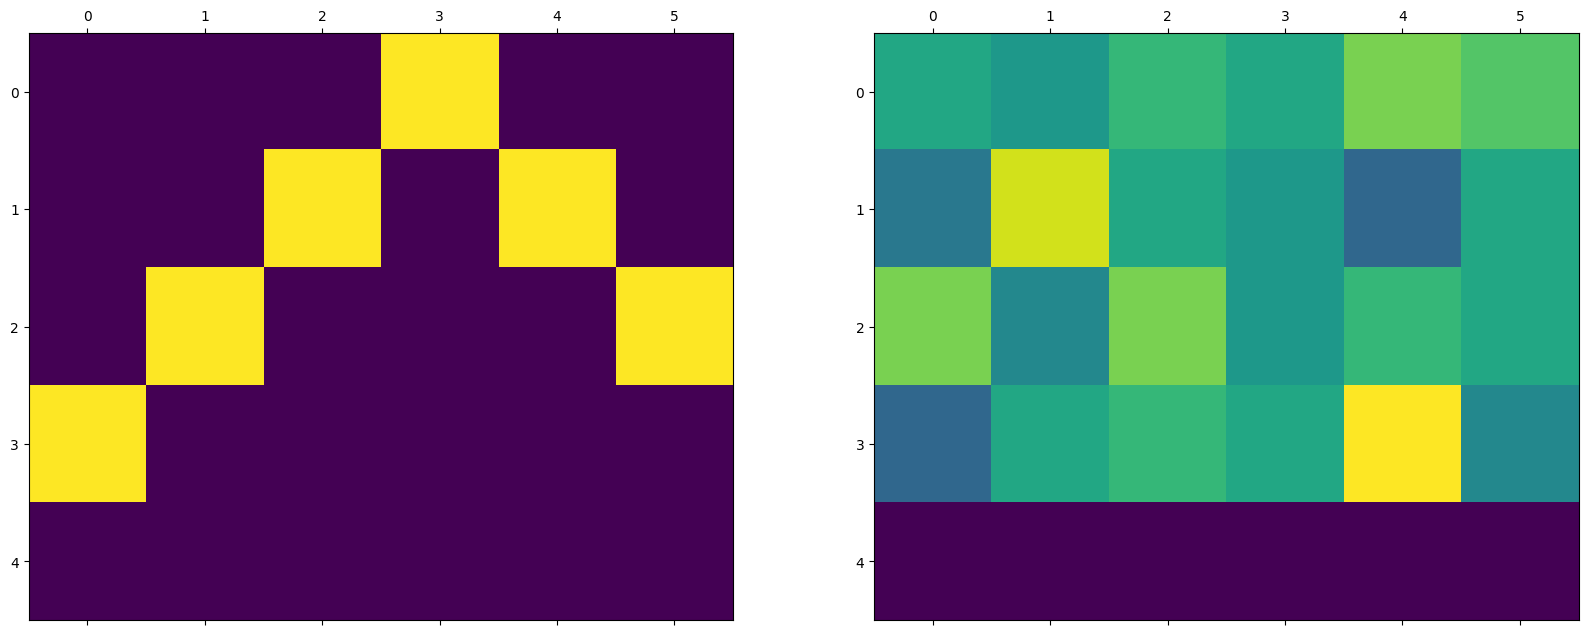

In [8]:
fig, ax = plt.subplots(1,2,figsize=(20,10))


ax[0].matshow(np.array(rules[1]))
ax[1].matshow(optm.output(optm.best_param))

